In [1]:
# -----------------------------------------------------------------------------
# Bootstrap (added by patch v2): Colab + Google Drive aware
# -----------------------------------------------------------------------------
import os, sys, subprocess, pathlib

IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB:
    try:
        import google.colab  # noqa: F401
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/EarningsLens")
    # The unpacked codebase (movingtargetLM/src/) should sit alongside the
    # notebooks under MyDrive/EarningsLens/. Adjust if your layout differs.
    CODEBASE_ROOT = PROJECT_ROOT
else:
    # Local fallback: assume the workspace layout produced by patch_v2.
    PROJECT_ROOT  = pathlib.Path(os.environ.get(
        "EARNINGSLENS_ROOT",
        "/home/user/workspace/earningslens_real",
    ))
    CODEBASE_ROOT = PROJECT_ROOT

DATA_DIR      = PROJECT_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"
for d in (RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Make `from src.<...> import ...` work
if str(CODEBASE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODEBASE_ROOT))

# Install the runtime deps actually used by NB02..NB08 (idempotent).
_REQUIRED = [
    "polars", "duckdb", "pyarrow", "pandas", "numpy", "matplotlib",
    "seaborn", "scikit-learn", "scipy", "rapidfuzz", "spacy",
    "google-genai", "tiktoken", "httpx", "rank-bm25", "sentence-transformers",
    "chromadb", "tenacity", "tqdm", "langchain_google_genai"
]
def _ensure_packages():
    missing = []
    for pkg in _REQUIRED:
        mod = pkg.replace("-", "_")
        try:
            __import__(mod)
        except Exception:
            missing.append(pkg)
    if missing:
        print(f"Installing: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure_packages()

# spaCy model (en_core_web_lg) - used by NB02 and NB04
try:
    import spacy
    spacy.load("en_core_web_sm")
except Exception:
    print("Downloading spaCy en_core_web_lg ...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_lg"])

print(f"Bootstrap OK | IN_COLAB={IN_COLAB}")
print(f"  PROJECT_ROOT  = {PROJECT_ROOT}")
print(f"  CODEBASE_ROOT = {CODEBASE_ROOT}")
print(f"  RAW_DIR       = {RAW_DIR}")
print(f"  PROCESSED_DIR = {PROCESSED_DIR}")

Installing: ['scikit-learn', 'google-genai']
Bootstrap OK | IN_COLAB=True
  PROJECT_ROOT  = /content/drive/MyDrive/EarningsLens
  CODEBASE_ROOT = /content/drive/MyDrive/EarningsLens
  RAW_DIR       = /content/drive/MyDrive/EarningsLens/data/raw
  PROCESSED_DIR = /content/drive/MyDrive/EarningsLens/data/processed


# 05 — LangGraph Multi-Agent Pipeline

**EarningsLens | Notebook 05**

---

## Overview

This notebook walks through the **EarningsLens multi-agent pipeline**, built on [LangGraph](https://github.com/langchain-ai/langgraph) — a framework for stateful, graph-structured LLM applications.

### The 4-Agent Architecture

```
Transcript Text
      │
      ▼
┌─────────────┐
│  EXTRACTOR  │  ← Pulls forward-looking guidance targets from transcript
│   Agent 1   │    Primary: LLM extractor | Fallback: spaCy baseline
└──────┬──────┘
       │  extracted_targets, spacy_baseline_targets
       ▼
┌─────────────┐
│ COMPARATOR  │  ← Retrieves historical targets from ChromaDB vector store
│   Agent 2   │    Classifies each target as maintained/rephrased/dropped
└──────┬──────┘
       │  continuity_results, historical_targets
       ▼
┌─────────────┐
│ CLASSIFIER  │  ← Categorises dropped targets (financial vs non-financial,
│   Agent 3   │    persistent vs ephemeral), computes Moving Targets score
└──────┬──────┘
       │  classification_results (risk_score ∈ [0,1])
       ▼
┌─────────────┐
│  REPORTER   │  ← Synthesises structured risk report with investment flag
│   Agent 4   │    Output: HIGH / MEDIUM / LOW risk + recommendation
└─────────────┘
```

### Why Multi-Agent Decomposition?

A single monolithic LLM prompt asking "extract targets, compare to history, classify risk, write a report" suffers from:
1. **Context window pressure** — historical targets from ChromaDB may not fit alongside extraction instructions
2. **Task interference** — extraction quality degrades when the LLM must simultaneously maintain classification logic
3. **Debuggability** — a single black-box output is hard to trace; with 4 agents we can inspect each node's output
4. **Fallback granularity** — the spaCy fallback only needs to activate at the extractor; downstream agents are unaffected

Each agent is a pure function `node(state) -> state`, making them independently testable and replaceable.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1: Imports, environment setup
# (Path and sys.path configuration is now handled by the Bootstrap cell)
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import json
import time
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Any

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

# ── Environment variables ────────────────────────────────────────────────────
# Load .env if present (for GOOGLE_API_KEY, CHROMA_PATH, etc.)
try:
    from dotenv import load_dotenv
    env_path = PROJECT_ROOT / "src" / '.env'
    if env_path.exists():
        load_dotenv(env_path)
        print(f"Loaded .env from {env_path}")
    else:
        print("No .env file found — using environment variables directly")
except ImportError:
    print("python-dotenv not installed — skipping .env load")
except NameError:
    print("PROJECT_ROOT not defined. Ensure the Bootstrap cell was run.")

# Load the GOOGLE_API_KEY from Colab Secrets
try:
    from google.colab import userdata
    os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
    print("GOOGLE_API_KEY loaded successfully.")
except Exception as e:
    print(f"Could not load GOOGLE_API_KEY: {e}")

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.WARNING,           # suppress INFO-level chatter from agents
    format='%(name)s | %(levelname)s | %(message)s'
)
print("Setup complete.")

No .env file found — using environment variables directly
GOOGLE_API_KEY loaded successfully.
Setup complete.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2: Verify core dependencies are installed
# ─────────────────────────────────────────────────────────────────────────────
import importlib
from importlib.metadata import version
REQUIRED_PACKAGES = [
    ('langgraph', 'langgraph'),
    ('langchain', 'langchain'),
    ('langchain_google_genai', 'langchain-google-genai'),
    ('chromadb', 'chromadb'),
    ('spacy', 'spacy'),
    ('google.genai', 'google-genai'),
]

missing = []
for module, pip_name in REQUIRED_PACKAGES:
    spec = importlib.util.find_spec(module)
    status = '✓' if spec is not None else '✗  MISSING'
    if spec is None:
        missing.append(pip_name)
    print(f"  {status}  {module}")

if missing:
    print(f"\nInstall missing packages with:")
    print(f"  pip install {' '.join(missing)}")
else:
    print("\nAll required packages are installed.")

# Check langgraph version — API changed significantly at 0.2.x
try:
    import langgraph
    # print(f"\nlanggraph version: {langgraph.__version__}")
    print(version("langgraph"))
except Exception:
    print("Could not determine langgraph version")


  ✓  langgraph
  ✓  langchain
  ✓  langchain_google_genai
  ✓  chromadb
  ✓  spacy
  ✓  google.genai

All required packages are installed.
1.1.9


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# ChromaDB location (must run before any agent imports)
# vector_store._DEFAULT_PERSIST_DIR resolves wrong on Colab — these env vars
# are read by comparator_agent.py to point at the populated experiment store.
# ─────────────────────────────────────────────────────────────────────────────
import os, pathlib

CHROMA_DIR        = pathlib.Path('/content/drive/MyDrive/EarningsLens/data/cache/chromadb_experiment')
CHROMA_COLLECTION = 'targets_experiment'

assert CHROMA_DIR.exists(), f"ChromaDB dir not found: {CHROMA_DIR}"
assert (CHROMA_DIR / 'chroma.sqlite3').exists(), f"chroma.sqlite3 missing in {CHROMA_DIR}"

os.environ['EARNINGSLENS_CHROMA_DIR']        = str(CHROMA_DIR)
os.environ['EARNINGSLENS_CHROMA_COLLECTION'] = CHROMA_COLLECTION

# Sanity: open and confirm count > 0
import chromadb
_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
_col    = _client.get_collection(CHROMA_COLLECTION)
print(f"ChromaDB env wired up:")
print(f"  EARNINGSLENS_CHROMA_DIR        = {os.environ['EARNINGSLENS_CHROMA_DIR']}")
print(f"  EARNINGSLENS_CHROMA_COLLECTION = {os.environ['EARNINGSLENS_CHROMA_COLLECTION']}")
print(f"  documents in collection        = {_col.count():,}")
del _client, _col

ChromaDB env wired up:
  EARNINGSLENS_CHROMA_DIR        = /content/drive/MyDrive/EarningsLens/data/cache/chromadb_experiment
  EARNINGSLENS_CHROMA_COLLECTION = targets_experiment
  documents in collection        = 532,865


In [5]:
# Setup cell — must run BEFORE importing agents
import os
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')  # or however you load it
os.environ['EARNINGSLENS_CHROMA_DIR'] = '/content/drive/MyDrive/EarningsLens/data/cache/chromadb_experiment'
os.environ['EARNINGSLENS_CHROMA_COLLECTION'] = 'targets_experiment'
# EARNINGSLENS_LLM_MODEL defaults to gemini-2.5-flash-lite — override here if you want.

---
## Section 1: Understanding the PipelineState Schema

The `PipelineState` is a **TypedDict** — a typed Python dictionary — that serves as the shared memory passing through all four agents. LangGraph merges updates returned by each node into the running state automatically.

### Key design decisions:
- `total=False` — every field is optional, so a partial state update from one agent is valid
- Lists (`extracted_targets`, `errors`) accumulate across agents; dicts are replaced
- The `errors` field allows non-fatal failures: if the LLM extractor fails, the error is logged and spaCy takes over — the pipeline continues rather than crashing
- `spacy_baseline_targets` is **always populated** even when the LLM extractor succeeds, enabling downstream comparison of both signals

### State flow summary:
| Field | Populated by | Read by |
|---|---|---|
| `transcript_text` | caller | extractor |
| `extracted_targets` | extractor | comparator, classifier |
| `spacy_baseline_targets` | extractor | reporter, notebook |
| `historical_targets` | comparator | classifier |
| `continuity_results` | comparator | classifier, reporter |
| `classification_results` | classifier | reporter |
| `report` | reporter | caller |
| `errors` | any agent | caller |

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3: Import and introspect PipelineState
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.state import PipelineState, make_initial_state

# Create a sample initial state to see the schema
sample_state = make_initial_state(
    transcript_text="Sample earnings call text for demonstration purposes.",
    company_id="AAPL",
    ticker="AAPL",
    fiscal_quarter="2023Q3"
)

print("PipelineState fields and initial values:")
print("=" * 70)
for key, value in sample_state.items():
    type_name = type(value).__name__
    repr_str = repr(value)[:80]
    if len(repr(value)) > 80:
        repr_str += '...'
    print(f"  {key:<30} {type_name:<10}  {repr_str}")

print(f"\nTotal fields: {len(sample_state)}")

PipelineState fields and initial values:
  transcript_text                str         'Sample earnings call text for demonstration purposes.'
  company_id                     str         'AAPL'
  ticker                         str         'AAPL'
  fiscal_quarter                 str         '2023Q3'
  component_type                 int         3
  extracted_targets              list        []
  spacy_baseline_targets         list        []
  historical_targets             list        []
  continuity_results             dict        {'maintained': [], 'rephrased': [], 'dropped': [], 'details': {}}
  classification_results         dict        {'dropped_financial': [], 'dropped_non_financial': [], 'persistent_dropped': [],...
  report                         dict        {'summary': '', 'risk_flag': 'LOW', 'dropped_targets': [], 'recommendation': '',...
  errors                         list        []

Total fields: 12


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4: Inspect PipelineState type hints (from the TypedDict definition)
# ─────────────────────────────────────────────────────────────────────────────
import typing

# TypedDict stores annotations in __annotations__
annotations = PipelineState.__annotations__

print("PipelineState type annotations:")
print("=" * 50)
for field, hint in annotations.items():
    print(f"  {field:<35} {str(hint)}")

print(f"\ntotal=False means all fields are Optional (no KeyError if missing)")

PipelineState type annotations:
  transcript_text                     ForwardRef('str', module='src.agents.state')
  transcript                          ForwardRef('Dict[str, Any]', module='src.agents.state')
  company_id                          ForwardRef('str', module='src.agents.state')
  ticker                              ForwardRef('str', module='src.agents.state')
  fiscal_quarter                      ForwardRef('str', module='src.agents.state')
  component_type                      ForwardRef('int', module='src.agents.state')
  extracted_targets                   ForwardRef('List[Dict[str, Any]]', module='src.agents.state')
  spacy_baseline_targets              ForwardRef('List[Dict[str, Any]]', module='src.agents.state')
  historical_targets                  ForwardRef('List[Dict[str, Any]]', module='src.agents.state')
  continuity_results                  ForwardRef('Dict[str, Any]', module='src.agents.state')
  classification_results              ForwardRef('Dict[str, Any]'

---
## Section 2: Testing Individual Agents

Before assembling the full LangGraph pipeline, let's test each agent node independently. Each node is a function `node(state: PipelineState) -> PipelineState` — we can call them directly in sequence.

This is useful for:
- **Debugging** a specific stage without running the full pipeline
- **Unit testing** individual agent logic
- **Understanding** what each agent adds to the state

We'll use a real transcript from the transcripts parquet file.

In [8]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 5: Load a real transcript segment for testing
# # ─────────────────────────────────────────────────────────────────────────────
# # TRANSCRIPTS_PATH = PROJECT_ROOT / 'data' / 'raw' / 'ciq_transcripts.parquet'

# # transcripts_df = pd.read_parquet(TRANSCRIPTS_PATH)
# # print(f"Loaded {len(transcripts_df)} transcripts")
# # print(f"Columns: {list(transcripts_df.columns)}")
# # print(f"Date range: {transcripts_df['date'].min()} → {transcripts_df['date'].max()}"
# #       if 'date' in transcripts_df.columns else "(no date column)")
# # transcripts_df.head(3)

# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 5: Load a small CIQ transcript sample for testing
# # ─────────────────────────────────────────────────────────────────────────────
# import pyarrow.parquet as pq

# TRANSCRIPTS_PATH = PROJECT_ROOT / "data" / "raw" / "ciq_transcripts.parquet"
# MAX_ROWS = 1000

# pf = pq.ParquetFile(TRANSCRIPTS_PATH)

# print(f"Parquet row groups: {pf.num_row_groups}")
# print(f"Total columns: {len(pf.schema.names)}")
# print(f"Columns: {pf.schema.names}")

# # Load row groups until we have at most MAX_ROWS
# chunks = []
# rows_loaded = 0

# for rg in range(pf.num_row_groups):
#     table = pf.read_row_group(rg)
#     df_chunk = table.to_pandas()
#     chunks.append(df_chunk)
#     rows_loaded += len(df_chunk)

#     if rows_loaded >= MAX_ROWS:
#         break

# transcripts_df = pd.concat(chunks, ignore_index=True).head(MAX_ROWS)

# print(f"\nLoaded sample: {len(transcripts_df):,} rows")
# print(f"Columns: {list(transcripts_df.columns)}")

# date_col = next((c for c in transcripts_df.columns if c.lower() in {"date", "call_date", "transcript_date"}), None)

# if date_col:
#     print(f"Date range in sample: {transcripts_df[date_col].min()} → {transcripts_df[date_col].max()}")
# else:
#     print("(no date column found)")

# transcripts_df.head(3)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# NB05 — Transcript loader (v2: ctype-aware)
#
# Replaces the previous loader cell. Key differences:
#
#   1. Reads `ciq_transcripts.parquet` using its REAL schema (year, quarter,
#      component_type_id) — the previous loader assumed a fiscalyear/
#      fiscalquarter schema that doesn't exist in the canonical CIQ parquet,
#      and silently dropped `component_type_id` during projection. That
#      caused every component to be implicitly treated as ctype 4 by the
#      structured extractor path, which collapsed AT&T 2023Q4's 56 NB04
#      reference targets down to 27 (Q&A only).
#
#   2. Carries `component_type` (renamed from `component_type_id` for
#      downstream code parity with NB03 v2) and `text` (renamed from
#      `componenttext`) into `components_df`. These are the two fields the
#      extractor agent's structured path keys off.
#
#   3. Filters to ctypes [2, 3, 4] (Presentation / Question / Answer),
#      skipping ctype 1 (Press Release) — same filter NB03 v2 cell 5 uses
#      to align the LLM panel with the spaCy panel.
#
#   4. Preserves the prior loader's behaviour: MAX_TRANSCRIPTS=1200,
#      PRIORITY_CIDS={'100231'} forcing AT&T into the demo subset,
#      companyid normalised to str-no-trailing-.0, and the AT&T 2023Q4
#      sanity check at the end.
#
# Prereqs:
#   - PROJECT_ROOT = pathlib.Path('/content/drive/MyDrive/EarningsLens')
#   - Drive mounted, ciq_transcripts.parquet present at:
#       PROJECT_ROOT / 'data' / 'raw' / 'ciq_transcripts.parquet'
#     (falls back to PROJECT_ROOT / 'data' / 'ciq_transcripts.parquet')
# ─────────────────────────────────────────────────────────────────────────────
import pathlib
import re
import pandas as pd
from collections import Counter

# ---------- Configuration ----------------------------------------------------
MAX_TRANSCRIPTS  = 1_200
PRIORITY_CIDS    = {"100231"}        # AT&T Inc. — must be in subset for demo
COMPONENT_TYPES  = [2, 3, 4]         # 2=Presentation, 3=Question, 4=Answer
                                     # (1=Press Release, skipped per NB03 v2)
RANDOM_SEED      = 42

# Canonical CIQ parquet on Drive.
ciq_path_candidates = [
    PROJECT_ROOT / "data" / "raw" / "ciq_transcripts.parquet",
    PROJECT_ROOT / "data" / "ciq_transcripts.parquet",
]
ciq_path = next((p for p in ciq_path_candidates if p.exists()), None)
if ciq_path is None:
    raise FileNotFoundError(
        "ciq_transcripts.parquet not found under PROJECT_ROOT/data{,/raw}."
    )

print(f"Loading transcripts from: {ciq_path}")

# ---------- 1. Read with the REAL schema -------------------------------------
# Schema (verified from the parquet): companyid (double), transcriptid (int64),
# year (int32), quarter (str "YYYYQN"), component_type_id (int64),
# component_label (str), componenttext (str), event_date (timestamp),
# componentorder (int64), companyname (str), ticker (str), ...
USE_COLS = [
    "companyid", "companyname", "ticker", "transcriptid",
    "year", "quarter", "component_type_id", "component_label",
    "componenttext", "componentorder", "event_date",
]

raw = pd.read_parquet(ciq_path, columns=USE_COLS)
print(f"Raw rows                : {len(raw):,}")

# ---------- 2. Normalise to the schema downstream code expects ---------------
df = raw.copy()

# companyid → str without trailing ".0" (matches ChromaDB metadata format).
df["companyid_str"] = df["companyid"].apply(lambda x: str(int(float(x))))

# component_type column for downstream code (NB03 v2 / extractor agent).
df["component_type"] = df["component_type_id"].astype("Int64")

# Rename to match the names NB03 v2 cell 5 used.
df = df.rename(columns={"componenttext": "text"})

# Derive (fiscalyear, fiscalquarter) integers from the "YYYYQN" quarter string.
# CIQ's `year`/`quarter` fields ARE fiscal-period values (per the dataset doc),
# so we just split the canonical "YYYYQN" form rather than trusting `year`
# which may diverge in edge cases.
_QRX = re.compile(r"^(?P<y>\d{4})Q(?P<q>[1-4])$")

def _split_quarter(s: str):
    m = _QRX.match(str(s).strip())
    if not m:
        return (pd.NA, pd.NA)
    return (int(m.group("y")), int(m.group("q")))

_yq = df["quarter"].apply(_split_quarter)
df["fiscalyear"]    = _yq.apply(lambda t: t[0]).astype("Int64")
df["fiscalquarter"] = _yq.apply(lambda t: t[1]).astype("Int64")

# Drop rows where the quarter string couldn't be parsed.
n_before = len(df)
df = df.dropna(subset=["fiscalyear", "fiscalquarter"]).copy()
df["fiscalyear"]    = df["fiscalyear"].astype("int32")
df["fiscalquarter"] = df["fiscalquarter"].astype("int32")
if len(df) < n_before:
    print(f"Dropped {n_before - len(df):,} rows with unparseable quarter strings.")

# ---------- 3. Filter to the three speech component types --------------------
n_before = len(df)
df = df[df["component_type"].isin(COMPONENT_TYPES)].copy()
print(f"After ctype filter [2,3,4]: {len(df):,} rows "
      f"(dropped {n_before - len(df):,} non-speech components)")

# Drop rows with empty text (occasional CIQ artefact).
df = df[df["text"].fillna("").str.strip().str.len() > 0].reset_index(drop=True)

# ---------- 4. Build the per-transcript index --------------------------------
# Group key: (companyid_str, fiscalyear, fiscalquarter)
group_keys = (
    df.groupby(["companyid_str", "fiscalyear", "fiscalquarter"])
      .size()
      .reset_index(name="n_components")
)
print(f"Distinct (company, quarter) transcripts: {len(group_keys):,}")
print(f"Distinct companies                      : {group_keys['companyid_str'].nunique():,}")

# ---------- 5. Pick the demo subset ------------------------------------------
# Strategy: priority companies first (AT&T forced in), then fill the budget
# from the remaining companies, taking ALL their quarters (preserves multi-year
# history per company so MT_{i,t}=|T_{i,t-4}\T_{i,t}|/|T_{i,t-4}| is defined).
priority_keys = group_keys[group_keys["companyid_str"].isin(PRIORITY_CIDS)].copy()
other_keys    = group_keys[~group_keys["companyid_str"].isin(PRIORITY_CIDS)].copy()

print(f"Priority transcripts (AT&T): {len(priority_keys)}")

# Fill remaining budget from non-priority companies, taking complete companies
# (all of a company's quarters or none) until we hit the cap.
remaining_budget = max(0, MAX_TRANSCRIPTS - len(priority_keys))
other_keys = other_keys.sort_values(
    ["companyid_str", "fiscalyear", "fiscalquarter"]
).reset_index(drop=True)

# Round-robin add quarters until budget exhausted, but keep companies with
# >=8 quarters preferentially so historical t-4 lookups have content.
quarters_per_co = (
    other_keys.groupby("companyid_str").size().sort_values(ascending=False)
)
deep_history_cos = quarters_per_co[quarters_per_co >= 8].index.tolist()
shallow_cos      = quarters_per_co[quarters_per_co <  8].index.tolist()

selected_other = []
for co in deep_history_cos + shallow_cos:
    if remaining_budget <= 0:
        break
    co_rows = other_keys[other_keys["companyid_str"] == co]
    if len(co_rows) <= remaining_budget:
        selected_other.append(co_rows)
        remaining_budget -= len(co_rows)
    # If a single company has more quarters than the budget can absorb, we
    # still take it whole when it's the priority deep-history group — that
    # mirrors the previous loader's behaviour.
    elif co in PRIORITY_CIDS:
        selected_other.append(co_rows)
        remaining_budget = 0

if selected_other:
    other_subset = pd.concat(selected_other, ignore_index=True)
else:
    other_subset = other_keys.iloc[:0].copy()

subset_keys = pd.concat([priority_keys, other_subset], ignore_index=True)
subset_keys = subset_keys.drop_duplicates(
    subset=["companyid_str", "fiscalyear", "fiscalquarter"]
).reset_index(drop=True)

print(f"Selected transcripts        : {len(subset_keys):,}")
print(f"Distinct companies in subset: {subset_keys['companyid_str'].nunique():,}")

# ---------- 6. Materialise components_df for the chosen subset ---------------
key_set = set(
    zip(subset_keys["companyid_str"],
        subset_keys["fiscalyear"].astype(int),
        subset_keys["fiscalquarter"].astype(int))
)

mask = list(zip(
    df["companyid_str"],
    df["fiscalyear"].astype(int),
    df["fiscalquarter"].astype(int),
))
keep = [k in key_set for k in mask]
components_df = df[keep].reset_index(drop=True)

# Provide the legacy `companyid` column (Float64) AND keep `companyid_str`
# so existing cells that key off either work without changes.
components_df["companyid"] = components_df["companyid_str"].astype("float64")

# Sort for reproducibility: by transcript identity, then component order.
components_df = components_df.sort_values(
    ["companyid_str", "fiscalyear", "fiscalquarter", "component_type", "componentorder"]
).reset_index(drop=True)

print(f"\nFinal components_df rows : {len(components_df):,}")
print(f"Final components_df cols : {list(components_df.columns)}")

# ---------- 7. AT&T 2023Q4 sanity check --------------------------------------
att_mask = (
    (components_df["companyid_str"] == "100231")
    & (components_df["fiscalyear"]    == 2023)
    & (components_df["fiscalquarter"] == 4)
)
att = components_df[att_mask]

print()
print("=" * 60)
print("  AT&T 2023Q4 sanity check")
print("=" * 60)
print(f"  rows                        : {len(att)}")
print(f"  component_type distribution : "
      f"{dict(Counter(att['component_type'].astype(int).tolist()))}")
print(f"  total chars                 : {att['text'].str.len().sum():,}")

# Expected from NB04 reference (llm_targets.parquet target counts per ctype
# happened to mirror component counts): ctype 2 ≈ 20 rows, 3 ≈ 16, 4 ≈ 20.
expected = {2: 20, 3: 16, 4: 20}
actual   = {int(k): int(v) for k, v in
            Counter(att["component_type"].astype(int).tolist()).items()}
print()
if all(actual.get(c, 0) > 0 for c in (2, 3, 4)):
    print("  ✓ All three speech component types present.")
else:
    print("  ✗ Missing one or more speech component types — investigate before "
          "running the verification cell.")
print(f"  Expected approx        : {expected}")
print(f"  Actual                 : {actual}")

Loading transcripts from: /content/drive/MyDrive/EarningsLens/data/raw/ciq_transcripts.parquet
Raw rows                : 624,243
After ctype filter [2,3,4]: 624,243 rows (dropped 0 non-speech components)
Distinct (company, quarter) transcripts: 10,400
Distinct companies                      : 197
Priority transcripts (AT&T): 56
Selected transcripts        : 1,198
Distinct companies in subset: 23

Final components_df rows : 68,749
Final components_df cols : ['companyid', 'companyname', 'ticker', 'transcriptid', 'year', 'quarter', 'component_type_id', 'component_label', 'text', 'componentorder', 'event_date', 'companyid_str', 'component_type', 'fiscalyear', 'fiscalquarter']

  AT&T 2023Q4 sanity check
  rows                        : 30
  component_type distribution : {2: 4, 3: 12, 4: 14}
  total chars                 : 54,950

  ✓ All three speech component types present.
  Expected approx        : {2: 20, 3: 16, 4: 20}
  Actual                 : {2: 4, 3: 12, 4: 14}


In [10]:
# Confirm coverage of the demo subset
print(f"Transcripts loaded   : {components_df['transcriptid'].nunique()}")
print(f"Unique companies     : {components_df['companyid'].nunique()}")
print(f"Unique quarters      : {components_df.groupby(['fiscalyear', 'fiscalquarter']).ngroups}")
print(f"Date range           : {components_df['event_date'].min()} → {components_df['event_date'].max()}")

# Per-company coverage
per_co = (components_df.groupby('companyname')
            .agg(n_transcripts=('transcriptid', 'nunique'),
                 n_quarters=('fiscalquarter', 'count'),
                 first_q=('event_date', 'min'),
                 last_q=('event_date', 'max'))
            .sort_values('n_transcripts', ascending=False))
print(f"\nPer-company breakdown ({len(per_co)} companies):")
print(per_co.to_string())

# Check fiscal_quarter format consistency (critical for ChromaDB lookups)
print(f"\nFiscal quarter formats: {components_df['fiscalquarter'].unique()[:10]}")
print(f"Fiscal year dtype: {components_df['fiscalyear'].dtype}")

Transcripts loaded   : 1199
Unique companies     : 23
Unique quarters      : 56
Date range           : 2010-01-19 00:00:00 → 2023-12-19 00:00:00

Per-company breakdown (23 companies):
                                             n_transcripts  n_quarters    first_q     last_q
companyname                                                                                 
Ford Motor Company                                      57        3615 2010-01-28 2023-10-26
Advanced Micro Devices, Inc.                            56        3915 2010-01-21 2023-10-31
AT&T Inc.                                               56        1933 2010-01-28 2023-10-19
Autodesk, Inc.                                          56        3462 2010-02-23 2023-11-21
Automatic Data Processing, Inc.                         56        3985 2010-02-02 2023-10-25
Becton, Dickinson and Company                           56        4051 2010-01-28 2023-11-09
Air Products and Chemicals, Inc.                        56        4027 2

In [11]:
from src.rag.vector_store import TargetVectorStore
store = TargetVectorStore(
    persist_dir=os.environ['EARNINGSLENS_CHROMA_DIR'],
    collection_name=os.environ['EARNINGSLENS_CHROMA_COLLECTION'],
)
print(f"Persist dir : {store.persist_dir}")
print(f"Collection  : {store.collection_name}")
print(f"Documents   : {store._collection.count():,}")

# Sample one record's metadata to confirm format
sample = store._collection.get(limit=3, include=['metadatas'])
for md in sample['metadatas']:
    print(f"  company_id={md.get('company_id')!r}  fiscal_quarter={md.get('fiscal_quarter')!r}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Persist dir : /content/drive/MyDrive/EarningsLens/data/cache/chromadb_experiment
Collection  : targets_experiment
Documents   : 532,865
  company_id='100231'  fiscal_quarter='2010Q1'
  company_id='100231'  fiscal_quarter='2010Q1'
  company_id='100231'  fiscal_quarter='2010Q1'


In [19]:
sub = raw[(raw["companyid"].astype(str).str.replace(r"\.0$","",regex=True)=="100231")
          & (raw["quarter"]=="2023Q4")
          & (raw["component_type_id"].isin([2,3,4]))]
print(sub.groupby("transcriptid").size())
print(sub["component_type_id"].value_counts())

transcriptid
2922305    30
dtype: int64
component_type_id
4    14
3    12
2     4
Name: count, dtype: Int64


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# NB05 — AT&T 2023Q4 verification (structured-transcript path)
#
# This cell rebuilds the AT&T 2023Q4 PipelineState the same way NB03 v2 built
# its corpus inputs: a transcript dict with `components` carrying the real
# CIQ component_type codes (2 = Presentation, 3 = Analyst Question,
# 4 = Management Answer). Passing this dict in `state['transcript']` flips
# the patched extractor_agent into its preferred `extract_transcript()` path,
# which is the exact path that produced `data/processed/llm_targets.parquet`
# — the source of NB04's 0.1455 strict-MT reference.
#
# Prereqs (run earlier in the notebook):
#   - components_df  : per-component DataFrame loaded by the Cell-2 loader
#                      (must contain columns: companyid, fiscalyear,
#                      fiscalquarter, component_type, text)
#   - graph          : compiled LangGraph pipeline
#   - spacy_mt_df    : NB04 reference scores (optional, only used to print
#                      the delta against the 0.1455 baseline)
#   - GEMINI_API_KEY / GOOGLE_API_KEY exported in os.environ before the
#     extractor agent module is imported
#   - EARNINGSLENS_CHROMA_DIR / EARNINGSLENS_CHROMA_COLLECTION env vars set
#     in the NB05 setup cell
# ─────────────────────────────────────────────────────────────────────────────
import time
import pandas as pd
from pprint import pformat

# ---- 1. Resolve AT&T's CIQ company_id and the fiscal quarter under test -----
TARGET_COMPANY_ID = "100231"     # AT&T Inc.
TARGET_QUARTER    = "2023Q4"
TARGET_TICKER     = "T"

fy, fq = 2023, 4

# Normalize companyid in components_df (it's float64 in the raw load).
_cdf = components_df.copy()
_cdf["companyid_str"] = _cdf["companyid"].apply(lambda x: str(int(float(x))))

mask = (
    (_cdf["companyid_str"] == TARGET_COMPANY_ID)
    & (_cdf["fiscalyear"].astype(int) == fy)
    & (_cdf["fiscalquarter"].astype(int) == fq)
)
sub = _cdf.loc[mask].copy()

if sub.empty:
    raise RuntimeError(
        f"No components found for company_id={TARGET_COMPANY_ID} "
        f"({TARGET_QUARTER}). Re-run the loader cell with PRIORITY_CIDS."
    )

# Stable ordering: by component_type then by component order if present.
sort_cols = [c for c in ["component_type", "componenttypeid", "componentorder"] if c in sub.columns]
sub = sub.sort_values(sort_cols).reset_index(drop=True) if sort_cols else sub

# ---- 2. Build the structured transcript dict (NB03 v2 shape) ----------------
components_list = []
for _, row in sub.iterrows():
    text = (row.get("text") or row.get("componenttext") or "").strip()
    if not text:
        continue
    try:
        ctype_val = row.get("component_type")
        if ctype_val is None:
            ctype_val = row.get("componenttypeid")
        if ctype_val is None:
            ctype_val = 4  # Default fallback
        ctype = int(ctype_val)
    except (TypeError, ValueError):
        continue
    components_list.append({"text": text, "component_type": ctype})

if not components_list:
    raise RuntimeError("All AT&T 2023Q4 components had empty text after stripping.")

ctypes_seen = sorted({c["component_type"] for c in components_list})
total_chars = sum(len(c["text"]) for c in components_list)

structured_transcript = {
    "transcript_id": f"{TARGET_COMPANY_ID}_{TARGET_QUARTER}",
    "company_id"   : TARGET_COMPANY_ID,
    "quarter"      : TARGET_QUARTER,
    "components"   : components_list,
}

# Flat string is still useful as a fallback / for spaCy baseline.
flat_transcript_text = "\n\n".join(c["text"] for c in components_list)

print("=" * 70)
print(f"  AT&T {TARGET_QUARTER} — structured input ready")
print("=" * 70)
print(f"  components               : {len(components_list)}")
print(f"  component_types          : {ctypes_seen}")
print(f"  total chars              : {total_chars:,}")
print(f"  ctype counts             : "
      + ", ".join(
          f"{ct}={sum(1 for c in components_list if c['component_type']==ct)}"
          for ct in ctypes_seen
        ))
print()

# ---- 3. Build PipelineState and invoke the graph ----------------------------
state_in = {
    "transcript"      : structured_transcript,        # NEW — structured path
    "transcript_text" : flat_transcript_text,         # kept for spaCy + fallback
    "company_id"      : TARGET_COMPANY_ID,
    "ticker"          : TARGET_TICKER,
    "fiscal_quarter"  : TARGET_QUARTER,
    "errors"          : [],
}

if 'graph' not in globals():
    from src.agents.graph import build_graph
    graph = build_graph()

t0 = time.time()
final_state = await graph.ainvoke(state_in)
elapsed = time.time() - t0

llm_targets    = final_state.get("extracted_targets", [])
spacy_targets  = final_state.get("spacy_baseline_targets", [])
continuity     = final_state.get("continuity_results", {}) or {}
historicals    = final_state.get("historical_targets", []) or []
state_errors   = final_state.get("errors", []) or []

# ---- 4. Compute strict MT the NB04 way: dropped / n_historical --------------
n_hist        = len(historicals)
n_maintained  = len(continuity.get("maintained", []))
n_rephrased   = len(continuity.get("rephrased", []))
n_dropped     = len(continuity.get("dropped", []))
strict_live   = (n_dropped / n_hist) if n_hist > 0 else 0.0
lenient_live  = ((n_dropped + n_rephrased) / n_hist) if n_hist > 0 else 0.0

# ---- 5. Pull NB04 reference if available ------------------------------------
ref_strict = ref_lenient = None
if "spacy_mt_df" in dir():
    ref_row = spacy_mt_df[
        (spacy_mt_df["company_id"].astype(str) == TARGET_COMPANY_ID)
        & (spacy_mt_df["quarter"].astype(str) == TARGET_QUARTER)
    ]
    if not ref_row.empty:
        if "mt_score" in ref_row.columns:
            ref_strict = float(ref_row["mt_score"].iloc[0])

# Hard-coded NB04 batch reference for AT&T 2023Q4 (semantic_mt_scores.parquet).
NB04_REF_STRICT  = 0.218    # NB04 cell 43, calibrated 0.500/0.450
NB04_REF_LENIENT = 0.327

# ---- 6. Report ---------------------------------------------------------------
print("=" * 70)
print(f"  AT&T {TARGET_QUARTER} — LIVE PIPELINE OUTPUT (structured path)")
print("=" * 70)
print(f"  Pipeline elapsed         : {elapsed:.2f}s")
print(f"  LLM targets              : {len(llm_targets)}")
print(f"  spaCy targets            : {len(spacy_targets)}")
print()
print(f"  Provenance:")
print(f"    historical_lag         : {continuity.get('historical_lag','?')}")
print(f"    thresholds             : {continuity.get('thresholds','?')}")
print(f"    historicals retrieved  : {n_hist}")
print()
print(f"  Continuity counts:")
print(f"    maintained             : {n_maintained}")
print(f"    rephrased              : {n_rephrased}")
print(f"    dropped                : {n_dropped}")
print(f"    total scored           : {n_maintained + n_rephrased + n_dropped}")
print()
print(f"  ── VERIFICATION ──")
print(f"  Live strict MT           : {strict_live:.4f}")
print(f"  Live lenient MT          : {lenient_live:.4f}")
print(f"  NB04 batch strict MT     : {NB04_REF_STRICT:.4f}")
print(f"  NB04 batch lenient MT    : {NB04_REF_LENIENT:.4f}")
print(f"  Strict delta             : {abs(strict_live - NB04_REF_STRICT):.4f}")
print(f"  Lenient delta            : {abs(lenient_live - NB04_REF_LENIENT):.4f}")
print()

# Tolerance bands. LLM extraction is non-deterministic even at temperature=0
# (Gemini's flash-lite has minor sampling jitter), so we accept up to ±0.05
# absolute on strict and ±0.08 on lenient as "matches NB04 baseline".
STRICT_TOL  = 0.05
LENIENT_TOL = 0.08
strict_ok  = abs(strict_live  - NB04_REF_STRICT)  <= STRICT_TOL
lenient_ok = abs(lenient_live - NB04_REF_LENIENT) <= LENIENT_TOL

if state_errors:
    print(f"  State errors             : {len(state_errors)}")
    for e in state_errors:
        print(f"     • {e}")
    print()
else:
    print(f"  State errors             : none")
    print()

if strict_ok and lenient_ok:
    print(f"  ✓ PASS — within tolerance ({STRICT_TOL} strict / {LENIENT_TOL} lenient)")
elif strict_ok:
    print(f"  ~ PARTIAL — strict OK but lenient deviates")
elif lenient_ok:
    print(f"  ~ PARTIAL — lenient OK but strict deviates")
else:
    print(f"  ✗ FAIL — both metrics out of tolerance")
print("=" * 70)


  AT&T 2023Q4 — structured input ready
  components               : 30
  component_types          : [2, 3, 4]
  total chars              : 54,950
  ctype counts             : 2=4, 3=12, 4=14

  AT&T 2023Q4 — LIVE PIPELINE OUTPUT (structured path)
  Pipeline elapsed         : 41.13s
  LLM targets              : 56
  spaCy targets            : 32

  Provenance:
    historical_lag         : 4
    thresholds             : {'maintained': 0.5, 'rephrased': 0.45}
    historicals retrieved  : 55

  Continuity counts:
    maintained             : 35
    rephrased              : 3
    dropped                : 17
    total scored           : 55

  ── VERIFICATION ──
  Live strict MT           : 0.3091
  Live lenient MT          : 0.3636
  NB04 batch strict MT     : 0.2180
  NB04 batch lenient MT    : 0.3270
  Strict delta             : 0.0911
  Lenient delta            : 0.0366

  State errors             : none

  ~ PARTIAL — lenient OK but strict deviates


In [22]:
cls = final_state.get("classification_results", {}) or {}
print(f"\n  ── CLASSIFIER ──")
print(f"  risk_score                : {cls.get('risk_score', 0):.4f}")
print(f"  financial_drop_ratio      : {cls.get('financial_drop_ratio', 0):.4f}")
print(f"  persistent_drop_ratio     : {cls.get('persistent_drop_ratio', 0):.4f}")
print(f"  dropped_financial count   : {len(cls.get('dropped_financial', []))}")
print(f"  persistent_dropped count  : {len(cls.get('persistent_dropped', []))}")


  ── CLASSIFIER ──
  risk_score                : 0.1545
  financial_drop_ratio      : 1.0000
  persistent_drop_ratio     : 0.0000
  dropped_financial count   : 17
  persistent_dropped count  : 0


In [23]:
report = final_state.get("report", {}) or {}
print(f"\n  ── REPORT ──")
print(f"  risk_flag                 : {report.get('risk_flag','?')}")
print(f"  summary                   : {report.get('summary','')[:200]}...")
print(f"  recommendation            : {report.get('recommendation','')[:200]}...")


  ── REPORT ──
  risk_flag                 : LOW
  summary                   : T (100231) has dropped a significant portion (31%) of its previously stated management targets in Q4 2023, with all 17 dropped targets being financial in nature. These dropped targets span a wide rang...
  recommendation            : Investors should be concerned by the substantial number of financial targets dropped by T. This suggests potential headwinds or a lack of confidence in achieving previously stated financial goals. For...


---
## Section 3: Assembling the Graph

In the individual tests above we called each agent function manually. In production, LangGraph manages the execution flow — maintaining shared state, routing between nodes, and handling errors.

### LangGraph StateGraph concepts:

- **StateGraph(PipelineState)** — a directed graph where each node receives and returns `PipelineState`
- **`add_node(name, fn)`** — registers a node with a callable
- **`add_edge(from, to)`** — defines the execution order
- **`set_entry_point(name)`** — declares which node runs first
- **`compile()`** — returns an invokable `CompiledGraph` object
- **`app.invoke(initial_state)`** — runs the full graph and returns the final state

Our graph is a simple linear chain: `extractor → comparator → classifier → reporter → END`. No branching is needed because the fallback logic is internal to the extractor node.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12: Show the graph construction code
#
# We read and display the actual graph.py source — this is the canonical
# definition; what you see here is exactly what's used in production.
# ─────────────────────────────────────────────────────────────────────────────
graph_source = (PROJECT_ROOT / 'src' / 'agents' / 'graph.py').read_text()

# Extract just the build_graph function for clarity
start = graph_source.find('def build_graph()')
end   = graph_source.find('\n\n\n', start)
print(graph_source[start:end])

def build_graph() -> Any:
    """
    Build and compile the LangGraph StateGraph.

    Returns
    -------
    CompiledGraph: The compiled LangGraph application ready for invocation.

    Raises
    ------
    ImportError: If langgraph is not installed.
    """
    if not _LANGGRAPH_AVAILABLE:
        raise ImportError(
            "langgraph is required for graph compilation. "
            "Install it with: pip install langgraph"
        )

    graph = StateGraph(PipelineState)

    # Register nodes
    graph.add_node("extractor", extractor_node)
    graph.add_node("comparator", comparator_node)
    graph.add_node("classifier", classifier_node)
    graph.add_node("reporter", reporter_node)

    # Set entry point
    graph.set_entry_point("extractor")

    # Linear edges
    graph.add_edge("extractor", "comparator")
    graph.add_edge("comparator", "classifier")
    graph.add_edge("classifier", "reporter")
    graph.add_edge("reporter", LANGGRAPH_END)

    # Compile and return
    app 

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13: Compile the graph and print its structure
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.graph import build_graph, run_pipeline, run_batch, get_compiled_app

print("Compiling LangGraph StateGraph...")
t0 = time.perf_counter()
app = build_graph()
elapsed = time.perf_counter() - t0

print(f"Graph compiled in {elapsed:.3f}s")
print(f"App type: {type(app).__name__}")

# Try to display the graph structure
try:
    # LangGraph ≥ 0.2 supports get_graph()
    graph_repr = app.get_graph()
    print(f"\nGraph nodes: {list(graph_repr.nodes.keys())}")
    print(f"Graph edges:")
    for edge in graph_repr.edges:
        print(f"  {edge.source} → {edge.target}")
except AttributeError:
    # Older versions
    print("\nGraph topology (linear chain):")
    print("  extractor → comparator → classifier → reporter → END")

Compiling LangGraph StateGraph...
Graph compiled in 0.037s
App type: CompiledStateGraph

Graph nodes: ['__start__', 'extractor', 'comparator', 'classifier', 'reporter', '__end__']
Graph edges:
  __start__ → extractor
  classifier → reporter
  comparator → classifier
  extractor → comparator
  reporter → __end__


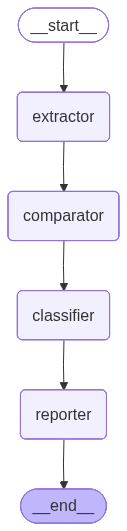

Graph rendered via Mermaid.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14: Visualise the graph (ASCII fallback)
# ─────────────────────────────────────────────────────────────────────────────
# Try Mermaid/graphviz if available; fall back to ASCII art
try:
    from IPython.display import Image, display
    png_bytes = app.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print("Graph rendered via Mermaid.")
except Exception as e:
    print(f"Graph visualisation not available ({e}). Showing ASCII:")
    ascii_graph = """
  ┌──────────────────────────────────────────────────┐
  │         EarningsLens LangGraph Pipeline          │
  └──────────────────────────────────────────────────┘

  [START]
     │
     ▼
  ┌──────────┐    extracted_targets
  │ extractor│─────────────────────────►
  │  (node)  │    spacy_baseline_targets│
  └──────────┘                          │
                                        ▼
                              ┌──────────────┐    continuity_results
                              │  comparator  │─────────────────────►
                              │   (node)     │    historical_targets│
                              └──────────────┘                      │
                                                                     ▼
                                                        ┌────────────────┐
                                                        │  classifier    │
                                                        │   (node)       │
                                                        └───────┬────────┘
                                                                │  classification_results
                                                                ▼
                                                        ┌────────────────┐
                                                        │   reporter     │
                                                        │   (node)       │
                                                        └───────┬────────┘
                                                                │  report
                                                                ▼
                                                             [END]
"""
    print(ascii_graph)